# Module 06 - Data Forensics và Reverse Engineering

**Mục tiêu.** Dataset có nhiều dấu hiệu được sinh tự động. Notebook
này ghi rõ cách phát hiện các công thức tất định, cách suy luận
ngưỡng nhãn `is_delayed`, và cách quyết định biến nào chỉ dùng để
audit/chẩn đoán thay vì đưa vào mô hình dự báo.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import pandas as pd
from IPython.display import Image
from pizza_dss.data_loader import load_dataset
from pizza_dss.data_forensics import (
    bootstrap_brand_delta_f2,
    brand_ablation,
    brand_homogeneity_tests,
    build_forensics_artifacts,
    deterministic_formula_audit,
    duration_generator_reconstruction,
    duration_model_recovery,
    feature_information_audit,
    infer_delay_threshold,
    mi_permutation_audit,
    uniformity_tests,
)

Sinh trước các hình forensics để hiển thị inline ở từng mục.

In [2]:
_ = build_forensics_artifacts()

## 0. Định nghĩa thuật ngữ forensics

- **Tất định (deterministic)**: cột tính được chính xác từ cột khác bằng
  một công thức; sai số tối đa ~0.
- **Lượng tử hóa (quantization)**: giá trị bị "ép" về một lưới rời rạc
  (ở đây duration chỉ nhận bội số 5 phút).
- **Mutual Information (MI)**: lượng thông tin (bit) mà một biến cho biết
  về nhãn; 0 = độc lập. **MI có điều kiện theo distance band** = MI còn
  lại *sau khi đã biết quãng đường*.
- **Permutation test**: xáo trộn ngẫu nhiên nhãn nhiều lần để dựng "mức
  nền do may rủi"; nếu giá trị quan sát không vượt mức nền thì đó là
  **nhiễu ước lượng**, không phải tín hiệu thật. Dùng để kiểm tra MI có
  bị thổi phồng bởi biến nhiều mức / mẫu nhỏ hay không.
- **Ablation**: bỏ một feature rồi đo mức sụt metric, để định lượng đóng
  góp thực của feature đó.
- **Bootstrap CI**: lấy mẫu lại có hoàn lại để ước lượng khoảng tin cậy;
  nếu CI chứa 0 thì hiệu ứng nằm trong nhiễu.

## 1. Nguyên tắc truy ngược

Cách làm không phải đoán bằng cảm tính. Với mỗi cột nghi là công
thức, nhóm:

1. nhìn tên cột và quan hệ nghiệp vụ có thể có;
2. đề xuất biểu thức ứng viên;
3. tính biểu thức cho toàn bộ 1.004 dòng;
4. đo `max_abs_error` giữa cột gốc và biểu thức;
5. chỉ gọi là tất định nếu sai số tối đa bằng 0 hoặc xấp xỉ 0.

In [3]:
df = load_dataset()
df.shape

(1004, 37)

## 2. Suy luận ngưỡng nhãn delayed

In [4]:
infer_delay_threshold(df).head(12)

,rule,operator,threshold_minutes,mismatches,mismatch_rate,accuracy,false_positives,false_negatives,predicted_delayed,actual_delayed,exact_match,max_observed_on_time_duration,min_observed_delayed_duration,interpretation
0,delivery_duration_min > 30,>,30.0,0,0.000000,1.000000,0,0,210,210,True,30.0,35.0,Observationally exact on this 5-minute duratio...
1,delivery_duration_min >= 35,>=,35.0,0,0.000000,1.000000,0,0,210,210,True,30.0,35.0,Observationally exact on this 5-minute duratio...
2,delivery_duration_min > 35,>,35.0,44,0.043825,0.956175,0,44,166,210,False,30.0,35.0,Does not reproduce the provided label exactly.
3,delivery_duration_min >= 40,>=,40.0,44,0.043825,0.956175,0,44,166,210,False,30.0,35.0,Does not reproduce the provided label exactly.
4,delivery_duration_min > 40,>,40.0,136,0.135458,0.864542,0,136,74,210,False,30.0,35.0,Does not reproduce the provided label exactly.
5,delivery_duration_min >= 45,>=,45.0,136,0.135458,0.864542,0,136,74,210,False,30.0,35.0,Does not reproduce the provided label exactly.
6,delivery_duration_min > 45,>,45.0,170,0.169323,0.830677,0,170,40,210,False,30.0,35.0,Does not reproduce the provided label exactly.
7,delivery_duration_min >= 50,>=,50.0,170,0.169323,0.830677,0,170,40,210,False,30.0,35.0,Does not reproduce the provided label exactly.
8,delivery_duration_min > 50,>,50.0,210,0.209163,0.790837,0,210,0,210,False,30.0,35.0,Does not reproduce the provided label exactly.
9,delivery_duration_min > 25,>,25.0,437,0.435259,0.564741,437,0,647,210,False,30.0,35.0,Does not reproduce the provided label exactly.


**Insight.** File chỉ cho nhãn `is_delayed`, không cho SLA. Threshold
sweep cho thấy `duration > 30` và `duration >= 35` đều khớp nhãn
tuyệt đối vì duration nằm trên lưới 5 phút. Do đó báo cáo phải nói
đây là ranh giới suy luận từ dữ liệu, không phải quy định thực tế.

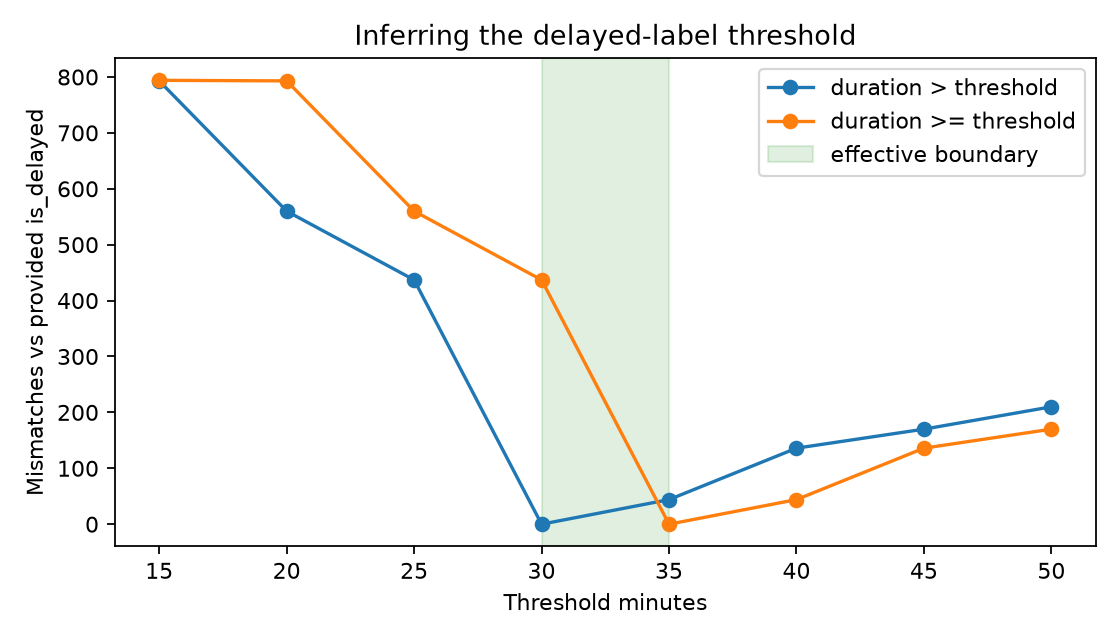

In [5]:
Image(filename=str(PROJECT_ROOT / "reports" / "figures" / "delay_threshold_inference.png"))

## 3. Bảy công thức/target tất định

In [6]:
deterministic_formula_audit(df)[
    ["column", "recovered_formula", "max_abs_error", "how_found", "verification_method", "matches_exactly"]
]

,column,recovered_formula,max_abs_error,how_found,verification_method,matches_exactly
0,estimated_duration_min,2.4 * distance_km,3.552714e-15,Scatter/ratio check: estimated_duration_min di...,Compute max absolute error between the column ...,True
1,topping_density,toppings_count / distance_km,2.220446e-16,Column name suggests a density; tested topping...,Compute max absolute error between the column ...,True
2,pizza_complexity,toppings_count * pizza_size_score,0.000000e+00,"Ordinal-encode pizza size as Small=1, Medium=2...",Compute max absolute error between the column ...,True
3,traffic_impact,"Low=1, Medium=2, High=3",0.000000e+00,Unique traffic_impact values are 1/2/3 and ali...,"Map traffic_level to Low=1, Medium=2, High=3 a...",True
4,delay_min,delivery_duration_min - estimated_duration_min,3.552714e-15,Delay conventionally means actual duration min...,Compute max absolute error between delay_min a...,True
5,delivery_efficiency_min_per_km,delivery_duration_min / distance_km,0.000000e+00,Column name indicates minutes per kilometer; t...,Compute max absolute error between the column ...,True
6,is_delayed,delivery_duration_min > 30,0.000000e+00,Threshold sweep over delivery_duration_min; th...,Compare is_delayed with candidate threshold ru...,True


**Quyết định.** Các cột hậu nghiệm như `delivery_duration_min`,
`delay_min`, `delivery_efficiency_min_per_km` và
`restaurant_avg_time` bị chặn khỏi feature model. Các cột trùng
thông tin như `estimated_duration_min`, `topping_density`,
`pizza_complexity`, `traffic_impact` được giữ cho audit/giải thích
nhưng không dùng trong feature set compact.

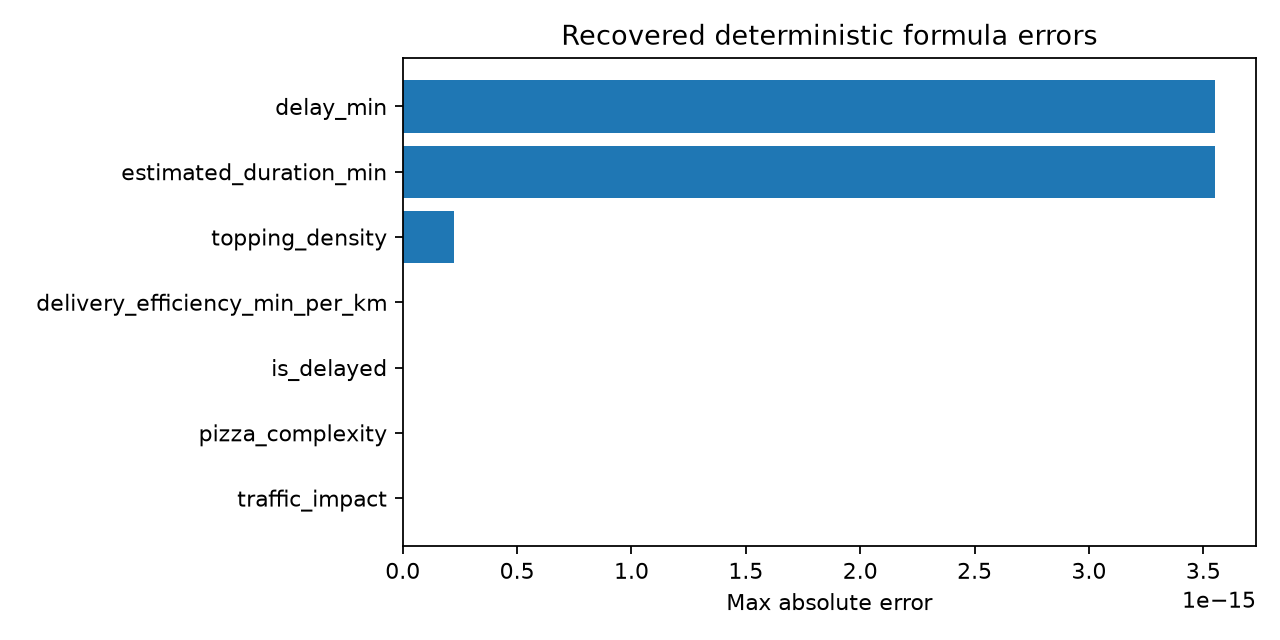

In [7]:
Image(filename=str(PROJECT_ROOT / "reports" / "figures" / "generator_deterministic_formula_errors.png"))

## 4. Luật lượng tử hóa duration

In [8]:
duration_model_recovery(df).round(4)

,term,coefficient,spec,r2,residual_mean,residual_std,residual_abs_mean,duration_grid_min,duration_grid_max,duration_grid_step,duration_multiple_of_5_share,unique_duration_values
0,intercept,11.5459,distance_only,0.8342,0.0,3.1570,2.6018,15,50,5,1.0,"15,20,25,30,35,40,45,50"
1,distance_km,3.6287,distance_only,0.8342,0.0,3.1570,2.6018,15,50,5,1.0,"15,20,25,30,35,40,45,50"
2,intercept,10.5311,distance_traffic,0.8364,0.0,3.1359,2.5465,15,50,5,1.0,"15,20,25,30,35,40,45,50"
3,distance_km,3.7212,distance_traffic,0.8364,0.0,3.1359,2.5465,15,50,5,1.0,"15,20,25,30,35,40,45,50"
4,traffic_level_Low,0.6539,distance_traffic,0.8364,0.0,3.1359,2.5465,15,50,5,1.0,"15,20,25,30,35,40,45,50"
5,traffic_level_Medium,0.9492,distance_traffic,0.8364,0.0,3.1359,2.5465,15,50,5,1.0,"15,20,25,30,35,40,45,50"
6,intercept,12.5972,distance_traffic_complexity,0.8754,-0.0,2.7365,2.2193,15,50,5,1.0,"15,20,25,30,35,40,45,50"
7,distance_km,4.2013,distance_traffic_complexity,0.8754,-0.0,2.7365,2.2193,15,50,5,1.0,"15,20,25,30,35,40,45,50"
8,traffic_level_Low,-1.2975,distance_traffic_complexity,0.8754,-0.0,2.7365,2.2193,15,50,5,1.0,"15,20,25,30,35,40,45,50"
9,traffic_level_Medium,-0.4843,distance_traffic_complexity,0.8754,-0.0,2.7365,2.2193,15,50,5,1.0,"15,20,25,30,35,40,45,50"


**Insight.** Duration chỉ có các mốc 15, 20, ..., 50 phút. Mô hình
tuyến tính theo distance/traffic/complexity giải thích được phần lớn
duration nhưng residual vẫn phản ánh việc generator snap về bội số
5 phút.

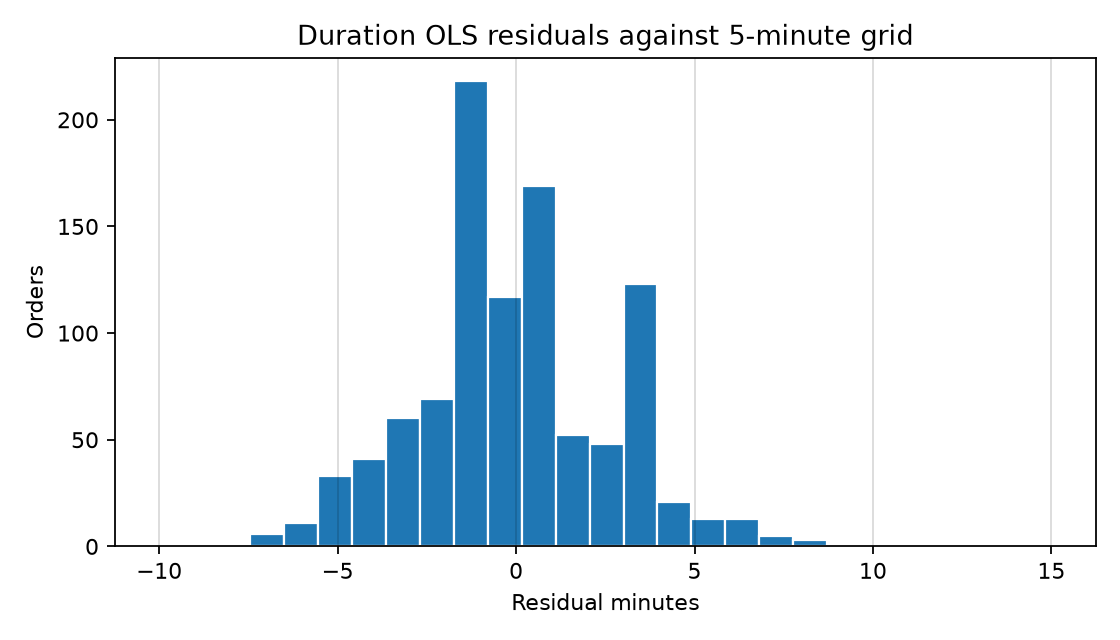

In [9]:
Image(filename=str(PROJECT_ROOT / "reports" / "figures" / "duration_model_residual_histogram.png"))

### 4b. Tái dựng generator của duration

Nếu duration thật sự là `round_to_5(base + noise)`, ta fit `base` theo
distance+traffic rồi đo: làm tròn dự đoán về lưới 5 phút có khớp duration
thật bao nhiêu %, và nhiễu lớn cỡ nào.

In [10]:
duration_generator_reconstruction(df)

,quantity,value,meaning
0,linear_r2,0.8364,Phần phương sai duration giải thích bởi distan...
1,residual_std_min,3.1359,Quy mô nhiễu quanh phần xác định (phút).
2,residual_within_2_5_min_share,0.5568,Tỷ lệ residual nằm trong nửa ô lưới 5 phút.
3,round5_reconstruction_accuracy,0.5568,Tỷ lệ round5(dự đoán tuyến tính) khớp đúng dur...
4,intercept_min,10.5311,"Thời gian nền khi distance=0, traffic gốc."


**Insight.** R² cao + tỷ lệ `round5(dự đoán)` khớp duration lớn ⇒ duration
gần như được sinh bởi một hàm xác định theo distance/traffic rồi làm tròn
5 phút, phần nhiễu nhỏ. Đây là lý do mô hình dự báo trễ "quá dễ": tín
hiệu gần tất định, không phản ánh độ khó thực tế.

## 5. Categorical artifact và tính đồng đều

In [11]:
feature_information_audit(df).round(6)

,feature,unique_values,raw_mi_bits,conditional_mi_given_distance_band_bits,mi_drop_after_distance_control_bits,verdict
2,location,84,0.210736,0.113425,0.097311,strong_artifact_signal_after_distance_control
3,pizza_type,12,0.144323,0.085193,0.059130,strong_artifact_signal_after_distance_control
1,restaurant_name,5,0.013291,0.052461,-0.039170,weak_artifact_or_sampling_signal_after_distanc...
0,payment_method,6,0.129158,0.051007,0.078151,weak_artifact_or_sampling_signal_after_distanc...
6,traffic_level,3,0.204841,0.028621,0.176220,weak_artifact_or_sampling_signal_after_distanc...
4,pizza_size,4,0.115201,0.017126,0.098075,noise_after_distance_control
5,is_weekend,2,0.000100,0.000071,0.000029,noise_after_distance_control


In [12]:
uniformity_tests(df).round(6)

,variable,test,categories,observed_counts,chi2,p_value,verdict
0,restaurant_name,chi-square GOF vs uniform over observed catego...,5,"{""Domino's"": 212, ""Little Caesars"": 199, ""Marc...",1.089641,0.895912,consistent_with_uniform
1,location,chi-square GOF vs uniform over observed catego...,84,"{""Akron, OH"": 2, ""Albuquerque, NM"": 59, ""Anahe...",2627.243028,0.000000,not_uniform
2,pizza_type,chi-square GOF vs uniform over observed catego...,12,"{""BBQ Chicken"": 54, ""Cheese Burst"": 188, ""Deep...",823.418327,0.000000,not_uniform
3,pizza_size,chi-square GOF vs uniform over observed catego...,4,"{""Large"": 240, ""Medium"": 429, ""Small"": 132, ""X...",192.310757,0.000000,not_uniform
4,toppings_count,chi-square GOF vs uniform 1-5,5,"{""1"": 43, ""2"": 198, ""3"": 319, ""4"": 240, ""5"": 204}",201.328685,0.000000,not_uniform
5,toppings_count,"chi-square GOF vs 1 + Binomial(4, 0.5)",5,"{""1"": 43, ""2"": 198, ""3"": 319, ""4"": 240, ""5"": 204}",344.624170,0.000000,not_binomial
6,toppings_count,"chi-square GOF vs 1 + Binomial(4, p_hat)",5,"{""1"": 43, ""2"": 198, ""3"": 319, ""4"": 240, ""5"": 204}",102.111574,0.000000,not_binomial


**Insight.** Một số categorical như location và pizza type còn tín
hiệu sau khi kiểm soát distance band. Vì vậy không thể nói mọi biến
categorical chỉ là noise độc lập; phải ghi rõ chúng có artifact từ
generator.

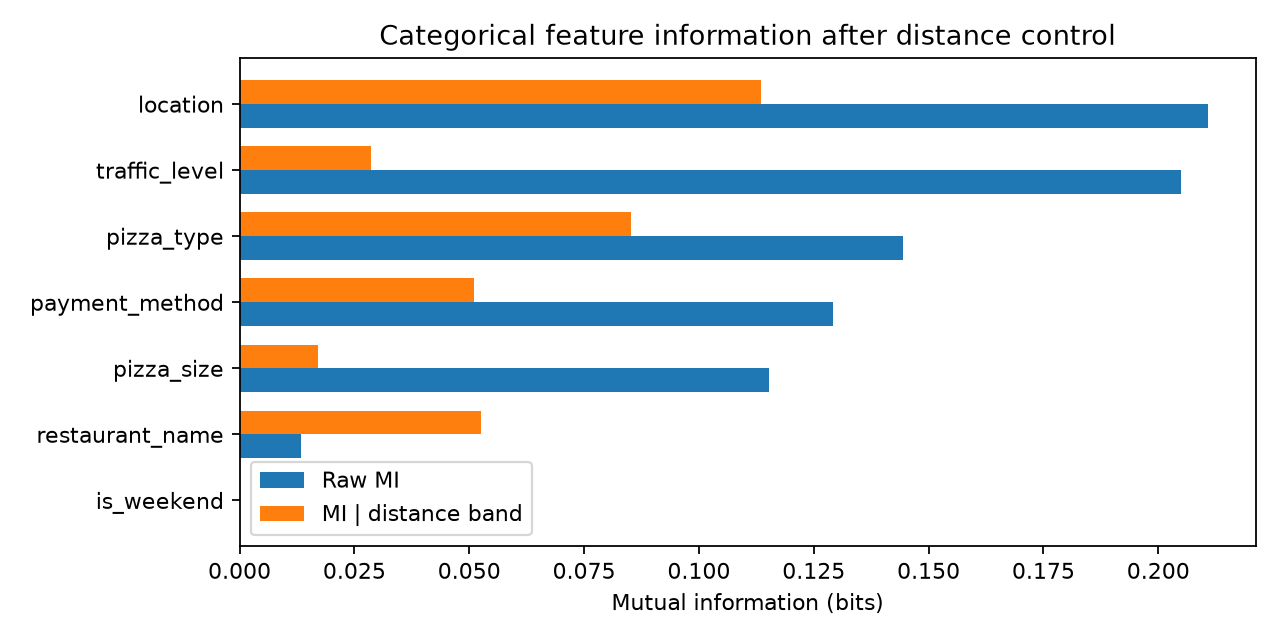

In [13]:
Image(filename=str(PROJECT_ROOT / "reports" / "figures" / "feature_information_audit.png"))

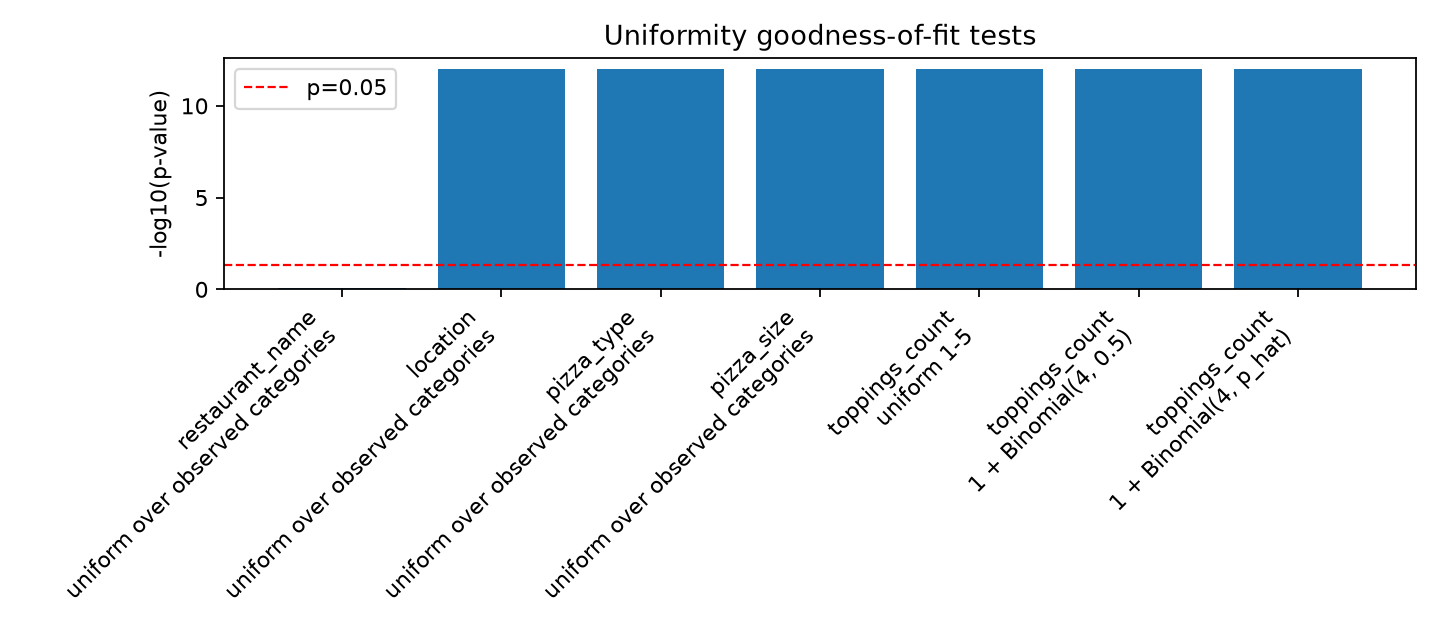

In [14]:
Image(filename=str(PROJECT_ROOT / "reports" / "figures" / "uniformity_tests.png"))

### 5b. Permutation test cho MI (chứng minh mức nhiễu nền)

MI plug-in bị thổi phồng với biến nhiều mức và mẫu nhỏ. Cell dưới xáo
trộn nhãn để dựng mức nền do may rủi, rồi so với MI quan sát.

In [15]:
mi_permutation_audit(df, n_perm=200).round(6)

,feature,unique_values,raw_mi_bits,conditional_mi_bits,permutation_null_mean_bits,permutation_null_p95_bits,excess_over_null_bits,p_value,verdict
0,payment_method,6,0.129158,0.051007,0.014243,0.022874,0.036764,0.004975,signal_beyond_chance
1,restaurant_name,5,0.013291,0.052461,0.012173,0.019672,0.040289,0.004975,signal_beyond_chance
3,pizza_type,12,0.144323,0.085193,0.015316,0.022924,0.069878,0.004975,signal_beyond_chance
4,pizza_size,4,0.115201,0.017126,0.006079,0.010242,0.011048,0.004975,signal_beyond_chance
6,traffic_level,3,0.204841,0.028621,0.004544,0.009356,0.024077,0.004975,signal_beyond_chance
2,location,84,0.210736,0.113425,0.128715,0.145670,-0.015290,0.935323,within_permutation_noise_floor
5,is_weekend,2,0.000100,0.000071,0.003105,0.006880,-0.003033,1.000000,within_permutation_noise_floor


**Insight.** Những feature có `p_value` lớn (vd `restaurant_name`,
`is_weekend`) nằm **trong mức nhiễu nền** — conditional MI dương của
chúng là *artifact ước lượng*, không phải tín hiệu thật. Chỉ feature có
`verdict = signal_beyond_chance` mới thực sự liên quan nhãn sau khi kiểm
soát distance. Đây là bằng chứng định lượng cho caveat MI-bias.

## 6. Brand có gộp thành một chuỗi được không?

In [16]:
brand_homogeneity_tests(df).round(4)

,restaurant_name,orders,delayed,delay_rate,delay_rate_ci_low,delay_rate_ci_high,pooled_delay_rate,ks_distance_stat,ks_distance_p_value,size_chi2,size_p_value,type_chi2,type_p_value,verdict
0,Domino's,212,62,0.2925,0.2312,0.3537,0.2092,0.2742,0.0,317.8965,0.0,269.5603,0.0,review_brand_difference
1,Little Caesars,199,45,0.2261,0.1680,0.2843,0.2092,0.3379,0.0,102.5531,0.0,57.0674,0.0,review_brand_difference
2,Marco's Pizza,195,36,0.1846,0.1302,0.2391,0.2092,0.3386,0.0,29.2460,0.0,194.4394,0.0,review_brand_difference
3,Papa John's,204,26,0.1275,0.0817,0.1732,0.2092,0.1971,0.0,83.2298,0.0,309.4856,0.0,review_brand_difference
4,Pizza Hut,194,41,0.2113,0.1539,0.2688,0.2092,0.1839,0.0,82.1199,0.0,60.9349,0.0,review_brand_difference


In [17]:
brand_ablation().round(4)

,model,accuracy,balanced_accuracy,precision,recall,f1,f2,mcc,roc_auc,tn,fp,fn,tp,feature_count,delta_f2_vs_with_restaurant,delta_mcc_vs_with_restaurant,interpretation
0,compact_with_restaurant,0.9701,0.9636,0.9091,0.9524,0.9302,0.9434,0.9117,0.9942,155,4,2,40,12,0.0000,0.0000,Reference model or non-negligible difference.
1,compact_without_restaurant,0.9652,0.9429,0.9268,0.9048,0.9157,0.9091,0.8938,0.9930,156,3,4,38,11,-0.0343,-0.0178,Restaurant name has a small measurable dev F2 ...


**Insight.** Có thể gộp brand để báo cáo cấp chuỗi, nhưng kiểm định
homogeneity không ủng hộ kết luận các brand giống hệt nhau. Vì vậy
dashboard nên cho phép lọc theo brand, còn báo cáo không kết luận
chất lượng thật của từng hãng.

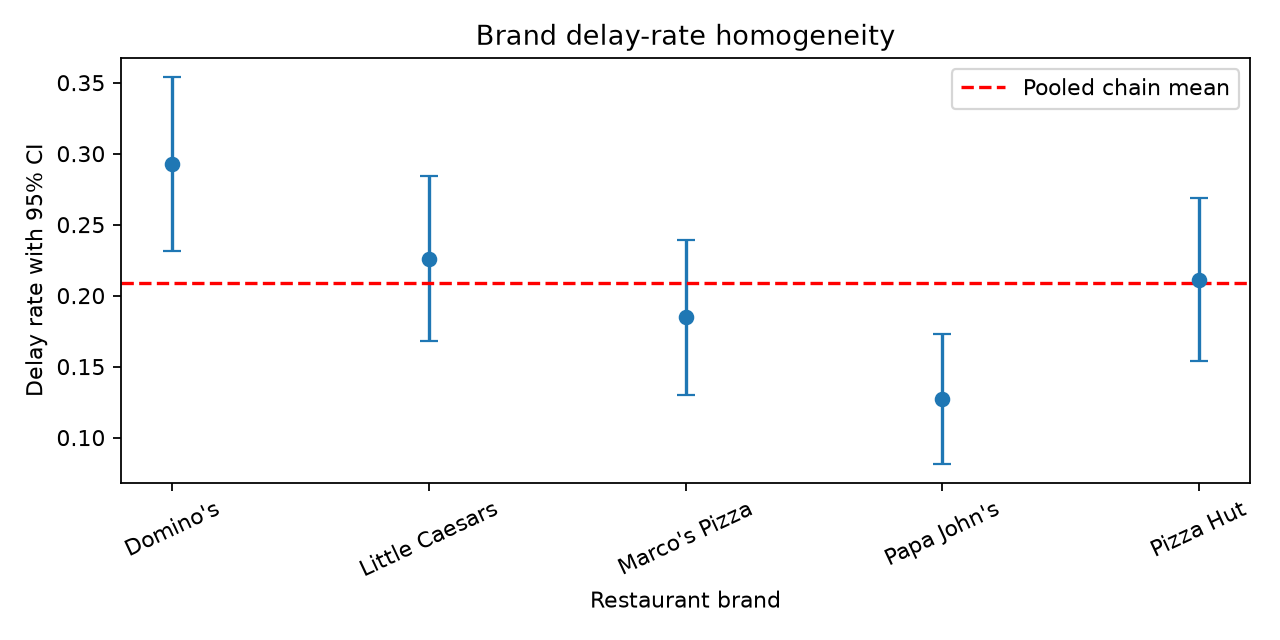

In [18]:
Image(filename=str(PROJECT_ROOT / "reports" / "figures" / "brand_delay_rate_homogeneity.png"))

**Caveat phương pháp.** MI có điều kiện theo distance band bị thiên
lệch dương với biến nhiều mức (location 84, type 12), và `restaurant_name`
có conditional MI tăng so với raw MI — dấu hiệu nhiễu mẫu nhỏ. Vì vậy
verdict "artifact" của các biến cardinality cao cần đọc thận trọng; với
brand, ưu tiên bằng chứng ablation ΔF2 hơn là MI. Kết luận brand cũng
chỉ trong giới hạn dev nhỏ (~42 ca trễ).

### 6b. Bootstrap khoảng tin cậy cho ΔF2 của brand

Lấy mẫu lại dev để xem hiệu ứng F2 khi thêm `restaurant_name` có khác 0
một cách đáng kể không.

In [19]:
bootstrap_brand_delta_f2(n_boot=2000)

,quantity,point_estimate,ci_low_2_5,ci_high_97_5,ci_includes_zero,n_boot,verdict
0,delta_f2_with_minus_without_restaurant,0.0343,-0.0096,0.0957,True,2000,within_noise


**Insight.** Nếu `ci_includes_zero = True`, mức ΔF2 của brand **nằm trong
nhiễu** ở cỡ dev này — không đủ bằng chứng để nói brand giúp dự báo. Kết
hợp với homogeneity test, brand chỉ dùng để *lọc/mô tả* trên dashboard,
tuyệt đối không kết luận "hãng tốt/xấu".

## 7. Xác nhận artifact

CSV/figure forensics đã sinh **một lần** ở Bước 0
(`build_forensics_artifacts`). Cell dưới chỉ liệt kê, không tính lại.

In [20]:
import os
forensic_files = sorted(
    f for f in os.listdir(PROJECT_ROOT / "reports" / "metrics")
    if f.startswith(("generator_", "duration_", "feature_information", "uniformity", "brand_", "mi_", "delay_threshold"))
)
{"n_forensic_metric_files": len(forensic_files), "files": forensic_files}

{'n_forensic_metric_files': 13,
 'files': ['brand_ablation.csv',
  'brand_delta_f2_bootstrap.csv',
  'brand_homogeneity_tests.csv',
  'delay_threshold_inference.csv',
  'duration_delay_profile.csv',
  'duration_generator_reconstruction.csv',
  'duration_grid_by_delay.csv',
  'duration_model_recovery.csv',
  'feature_information_audit.csv',
  'generator_deterministic_formulas.csv',
  'generator_reverse_engineering_summary.json',
  'mi_permutation_audit.csv',
  'uniformity_tests.csv']}